In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import astropy.io.fits as fits
import os

In [3]:
cube_temp = np.load('/home/xenoss/dat/thesis/dataset/dataset_v1/test/stokes_I_2_denorm.npy')
label_temp = np.load('/home/xenoss/dat/thesis/dataset/dataset_v1/test/velocities_2_denorm.npy')

cube_temp = (cube_temp - 0.4290209337687011 )/0.4057552461148396
label_temp = (label_temp + 2357.634521484375)/195649.671875

np.save('/home/xenoss/dat/thesis/dataset/dataset_v1/test/stokes_I_2.npy', cube_temp)
np.save('/home/xenoss/dat/thesis/dataset/dataset_v1/test/velocities_2.npy', label_temp)

In [2]:
main_path = "/home/xenoss/dat/thesis/data/"
dataset_version = 'v1'
cube_norm_path = os.path.join(main_path, dataset_version, "stacked/norm/")
stokes_I = np.load(os.path.join(cube_norm_path, 'stacked_inputs_i_light_log_normalized.npy'))
stokes_V = np.load(os.path.join(cube_norm_path, 'stacked_inputs_v_light_log_normalized.npy'))
    
vel_1 = np.load(os.path.join(cube_norm_path, 'stacked_velocities_1_normalized.npy'))
vel_1e_1 = np.load(os.path.join(cube_norm_path, 'stacked_velocities_0.1_normalized.npy'))
vel_1e_2 = np.load(os.path.join(cube_norm_path, 'stacked_velocities_0.01_normalized.npy'))
vel_1e_3 = np.load(os.path.join(cube_norm_path, 'stacked_velocities_0.001_normalized.npy'))
vel_1e_4 = np.load(os.path.join(cube_norm_path, 'stacked_velocities_0.0001_normalized.npy'))

print(stokes_I.shape)
print(stokes_V.shape)
print(vel_1.shape)
print(vel_1e_1.shape)
print(vel_1e_2.shape)
print(vel_1e_3.shape)
print(vel_1e_4.shape)

(31, 43, 768, 768)
(31, 43, 768, 768)
(30, 3, 768, 768)
(30, 3, 768, 768)
(30, 3, 768, 768)
(30, 3, 768, 768)
(30, 3, 768, 768)


In [3]:
# Open a cube with specific spanshot number:
cube = fits.open("/dat/milic/3D/3D_snapi_spectra/tumag_stokesIV_cube_150.fits")[0].data

# Note: all the data is in:
# /dat/milic/3D/3D_snapi_spectra/ 
# in fits format. 
# which should be accessible

In [11]:
cube.shape
# Indices are x,y, stokes component, wavelength

(768, 768, 4, 622)

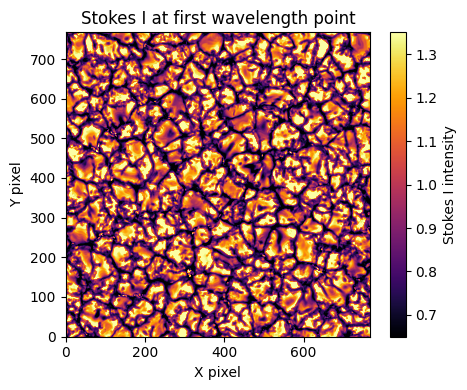

In [13]:
# Plot image at a specific wavelength: 
plt.figure(figsize=(5,4))
plt.imshow(cube[:,:,0,0].T, origin='lower', cmap='inferno', vmin=0.65, vmax=1.35)
plt.colorbar(label='Stokes I intensity')
plt.title('Stokes I at first wavelength point')
plt.xlabel('X pixel')
plt.ylabel('Y pixel')
plt.tight_layout()
plt.savefig('stokesI_first_wavelength.png', dpi=300)
plt.show()

In [5]:
# As always we will normalize the units for the intensity to something we have a better physical intuition about.
# In this case fits cubes are already normalized to the continuum intensity, so we will not do anything further.

In [22]:
# Now we want to make an image like the one up there, but with a slider that allows us to change the wavelength position interactively.
from ipywidgets import interact, IntSlider
@interact(wavelength_index=IntSlider(min=0, max=cube.shape[3]-1, step=1, value=0))
def plot_stokesI_at_wavelength(wavelength_index):
    plt.figure(figsize=(5,4))
    plt.imshow(cube[:,:,0,wavelength_index].T, origin='lower', cmap='inferno')
    plt.colorbar(label='Stokes I intensity (in units of I_qs)')
    plt.title(f'Stokes I at wavelength index {wavelength_index}')
    plt.xlabel('X pixel')
    plt.ylabel('Y pixel')
    plt.tight_layout()
    plt.show()

interactive(children=(IntSlider(value=0, description='wavelength_index', max=621), Output()), _dom_classes=('w…

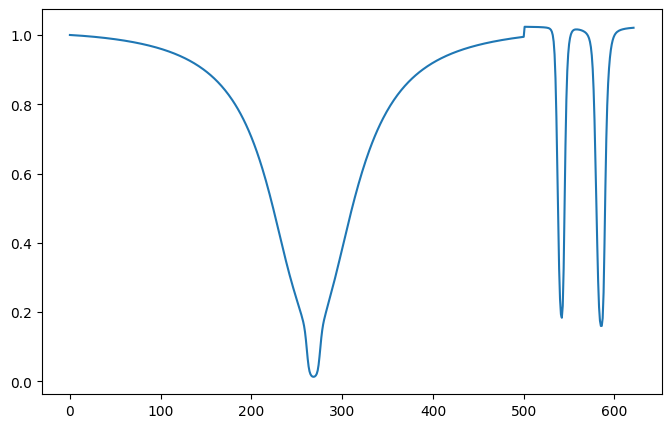

In [7]:
# to find interesting wavelength positions, we can plot the average spectrum over the whole cube:
mean_spectrum = np.mean(cube[:,:,0,:], axis=(0,1))
plt.figure(figsize=(8,5))
plt.plot(mean_spectrum)

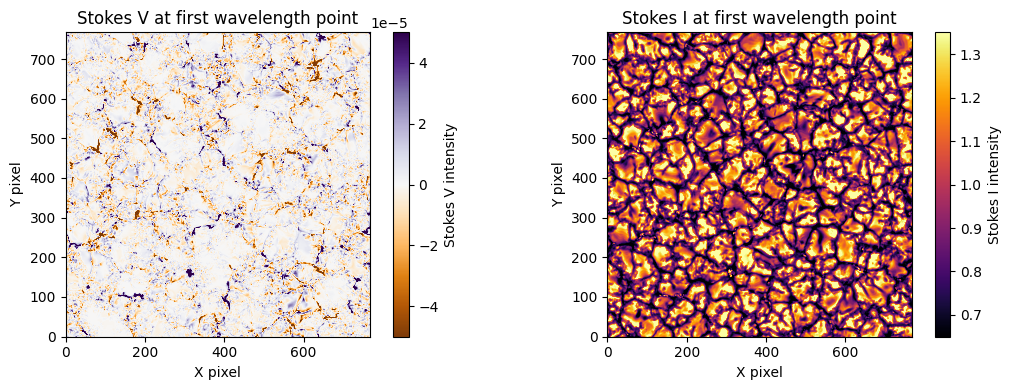

In [6]:
# Plot image at a specific wavelength: 
plt.figure(figsize=(11,4))
plt.subplot(1,2,1)
#plt.imshow(cube[:,:,3,265].T, origin='lower', cmap='inferno',vmin=0.0,vmax=0.3)
plt.imshow(cube[:,:,3,0].T, origin='lower', cmap='PuOr', vmin=-0.000050,vmax=0.000050)
plt.colorbar(label='Stokes V intensity')
plt.title('Stokes V at first wavelength point')
plt.xlabel('X pixel')
plt.ylabel('Y pixel')
plt.subplot(1,2,2)
plt.imshow(cube[:,:,0,0].T, origin='lower', cmap='inferno', vmin=0.65, vmax=1.35)
plt.colorbar(label='Stokes I intensity')
plt.title('Stokes I at first wavelength point')
plt.xlabel('X pixel')
plt.ylabel('Y pixel')
plt.tight_layout()

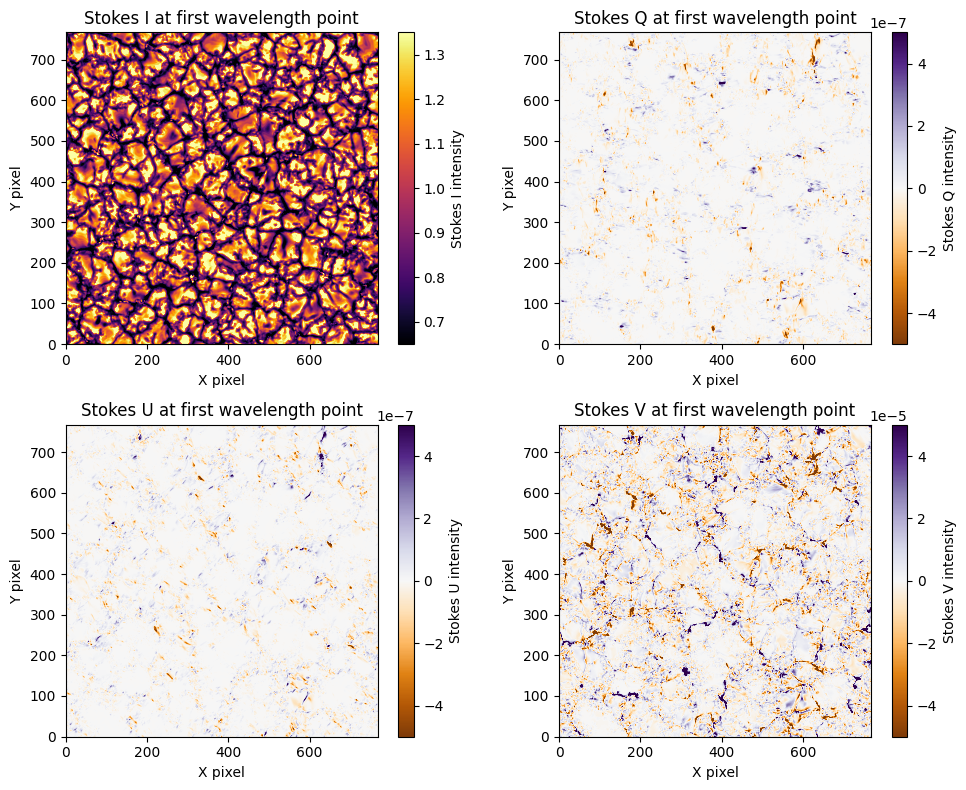

In [20]:
# Plot image at a specific wavelength: 
plt.figure(figsize=(10,8))
plt.subplot(2,2,1)
#plt.imshow(cube[:,:,3,265].T, origin='lower', cmap='inferno',vmin=0.0,vmax=0.3)
plt.imshow(cube[:,:,0,0].T, origin='lower', cmap='inferno',vmin=0.65, vmax=1.35)
plt.colorbar(label='Stokes I intensity')
plt.title('Stokes I at first wavelength point')
plt.xlabel('X pixel')
plt.ylabel('Y pixel')
plt.subplot(2,2,2)
plt.imshow(cube[:,:,1,0].T, origin='lower', cmap='PuOr', vmin = -0.5E-6, vmax=0.5E-6)
plt.colorbar(label='Stokes Q intensity')
plt.title('Stokes Q at first wavelength point')
plt.xlabel('X pixel')
plt.ylabel('Y pixel')
plt.subplot(2,2,3)
#plt.imshow(cube[:,:,3,265].T, origin='lower', cmap='inferno',vmin=0.0,vmax=0.3)
plt.imshow(cube[:,:,2,0].T, origin='lower', cmap='PuOr', vmin = -0.5E-6, vmax=0.5E-6)
plt.colorbar(label='Stokes U intensity')
plt.title('Stokes U at first wavelength point')
plt.xlabel('X pixel')
plt.ylabel('Y pixel')
plt.subplot(2,2,4)
plt.imshow(cube[:,:,3,0].T, origin='lower', cmap='PuOr',vmin=-0.000050,vmax=0.000050)
plt.colorbar(label='Stokes V intensity')
plt.title('Stokes V at first wavelength point')
plt.xlabel('X pixel')
plt.ylabel('Y pixel')
plt.tight_layout()
plt.savefig('stokes_params_at_first_wavelength.png', dpi=300)

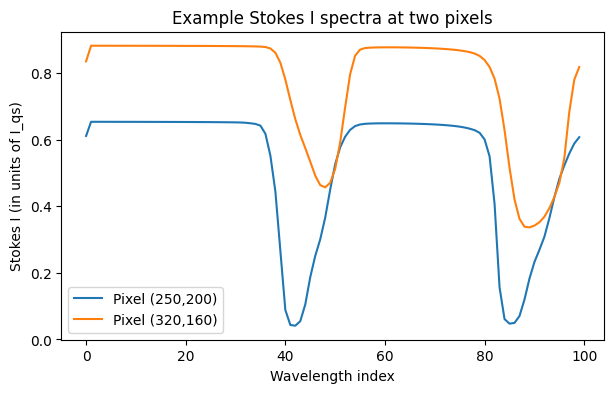

In [45]:
# Let's plot two example spectra:
plt.figure(figsize=(7,4))
plt.plot(cube[250,200,0,500:600], label='Pixel (250,200)')
plt.plot(cube[320,160,0,500:600], label='Pixel (320,160)')
plt.xlabel('Wavelength index')
plt.ylabel('Stokes I (in units of I_qs)')
plt.title('Example Stokes I spectra at two pixels')
plt.legend()

In [ ]:
logspacing = [np.logspace(np.log10(0.05), np.log10(3.0), 12)*dop_widths[i] + wav for i,wav in enumerate(center_wavelengths)]

new_wave_grid = [logspacing[i] for i in range(len(logspacing))]

stokes_I_downsampled = np.interp(new_wave_grid, old_wave_grid, cube[i,j,0,:])
stokes_I_downsampled_2 = np.interp(np.linspace(0, cube.shape[3], 32), np.arange(0, cube.shape[3]), cube[320,160,0,:]) 

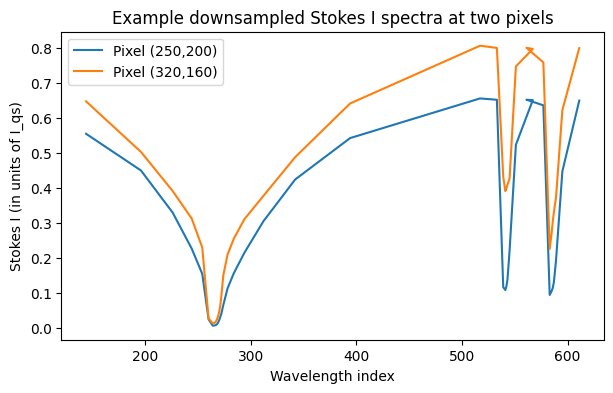

In [8]:
stokes_I_downsampled = np.load('/home/xenoss/dat/thesis/dummy_data/full_maps/downsampled_input_cubes/stokes_I/stokesI_0_downsampled.npy')
grid = np.load('/home/xenoss/dat/thesis/dummy_data/full_maps/downsampled_input_cubes/used_indices/indices_0_downsampled.npy')
plt.figure(figsize=(7,4))
plt.plot(grid, stokes_I_downsampled[:,250,200], label='Pixel (250,200)')
plt.plot(grid, stokes_I_downsampled[:,320,160], label='Pixel (320,160)')
plt.xlabel('Wavelength index')
plt.ylabel('Stokes I (in units of I_qs)')
plt.title('Example downsampled Stokes I spectra at two pixels')
plt.legend()


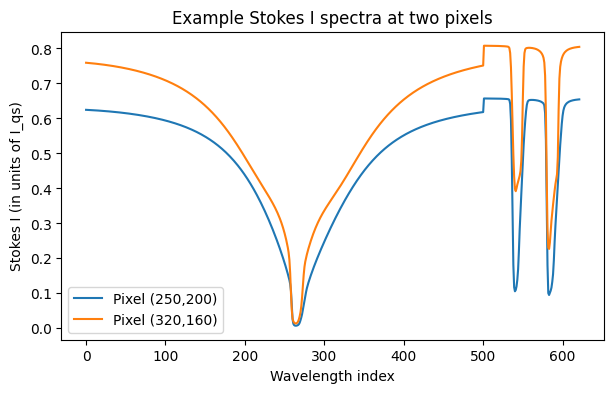

In [5]:
# Let's plot two example spectra:
plt.figure(figsize=(7,4))
plt.plot(cube[250,200,0,:], label='Pixel (250,200)')
plt.plot(cube[320,160,0,:], label='Pixel (320,160)')
plt.xlabel('Wavelength index')
plt.ylabel('Stokes I (in units of I_qs)')
plt.title('Example Stokes I spectra at two pixels')
plt.legend()

In [28]:
data0 = cube[250,200,0,:]
I0 = data0[:, :, 0, :]
I_mean = I0.mean(axis=(0,1))

ranges = [(200,380), (500,560), (560,620)]
line_centers = [np.argmin(I_mean[a:b]) + a for (a,b) in ranges]
print(line_centers)

[269, 542, 586]


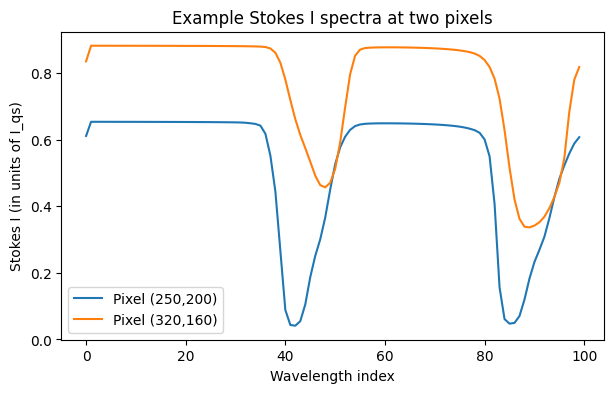

In [12]:
plt.figure(figsize=(7,4))
plt.plot(cube[250,200,0,500:600], label='Pixel (250,200)')
plt.plot(cube[320,160,0,500:600], label='Pixel (320,160)')
plt.xlabel('Wavelength index')
plt.ylabel('Stokes I (in units of I_qs)')
plt.title('Example Stokes I spectra at two pixels')
plt.legend()

In [ ]:
import sys
import os

proj_dir = os.path.abspath(os.path.join(os.getcwd(), 'DeepVel_3D_velocity'))
if proj_dir not in sys.path:
    sys.path.insert(0, proj_dir)
import muram as mio
# here we want to read the old muram format files directly to get the velocity cubes and compare to what we see here
# We are taking tau = - 1 here because we found earlier that one works the best.
murampath = '/dat/milic/2D'

muramslice = mio.MuramTauSlice(murampath,0,0.100) #path, iteration, tau
print(muramslice.vx[::2,::2].shape)

(768, 768)


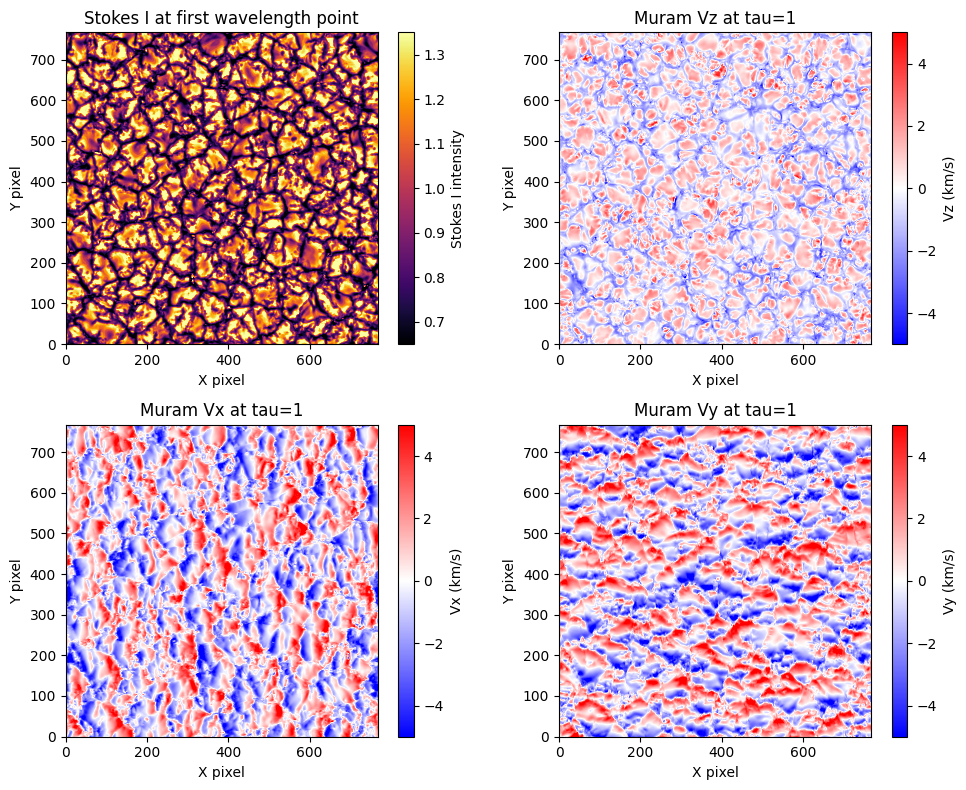

In [ ]:
# Now we want to compare our image with the velocity map from muram at tau=0.1
# Make it a 2x2 subplots, so that we can have intensity, vx, vy, vz
plt.figure(figsize=(10,8))
plt.subplot(2,2,1)
plt.imshow(cube[:,:,0,0].T, origin='lower', cmap='inferno', vmin=0.65, vmax=1.35)
plt.colorbar(label='Stokes I intensity')
plt.title('Stokes I at first wavelength point')
plt.xlabel('X pixel')
plt.ylabel('Y pixel')
plt.subplot(2,2,2)
plt.imshow(muramslice.vx[::2,::2].T/1E5, origin='lower', cmap='bwr', vmin=-5, vmax=5)
plt.colorbar(label='Vz (km/s)')
plt.title('Muram Vz at tau=0.1')
plt.xlabel('X pixel')
plt.ylabel('Y pixel')

plt.subplot(2,2,4)
plt.imshow(muramslice.vz[::2,::2].T/1E5, origin='lower', cmap='bwr', vmin=-5, vmax=5)
plt.colorbar(label='Vy (km/s)')
plt.title('Muram Vy at tau=0.1')
plt.xlabel('X pixel')
plt.ylabel('Y pixel')
plt.subplot(2,2,3)
plt.imshow(muramslice.vy[::2,::2].T/1E5, origin='lower', cmap='bwr', vmin=-5, vmax=5)
plt.colorbar(label='Vx (km/s)')
plt.title('Muram Vx at tau=0.1')
plt.xlabel('X pixel')
plt.ylabel('Y pixel')

plt.tight_layout()

In [ ]:
# So for the moment, we are only working with Stokes I 

# Once all the cubes are converted to fits, we can read them with astropy.io.fits

import pyana
from astropy.io import fits
for i in range(1350, 4650, 150):
    print (i)
    cube = pyana.fzread(f"/dat/milic/3D/3D_snapi_spectra/loc_dyn_32_32_16_{i}_tumag.f0")["data"]
    I_qs = np.mean(cube[:,:,0,:10])
    cube /= I_qs  # Now the intensity is in units of quiet sun intensity
    hdu = fits.PrimaryHDU(cube)
    hdu.writeto(f'/dat/milic/3D/3D_snapi_spectra/tumag_stokesIV_cube_{i}.fits', overwrite=True)
#cube = pyana.fzread("/dat/milic/3D/3D_snapi_spectra/loc_dyn_32_32_16_1200_tumag.f0")["data"]
#I_qs = np.mean(cube[:,:,0,:10])
#cube /= I_qs  # Now the intensity is in units of quiet sun intensity
#hdu = fits.PrimaryHDU(cube)
#hdu.writeto('/dat/milic/3D/3D_snapi_spectra/tumag_stokesIV_cube_1200.fits', overwrite=True)

1350
1500
1650
1800
1950
2100
2250
2400


In [3]:
cubes = os.listdir('/dat/milic/3D/3D_snapi_spectra/')
fits_cubes = []
for c in cubes:
    if 'fits' in c:
        # print (c)
        fits_cubes.append(c)
fits_cubes.sort()
print (fits_cubes)

['tumag_stokesIV_cube_0.fits', 'tumag_stokesIV_cube_1050.fits', 'tumag_stokesIV_cube_1200.fits', 'tumag_stokesIV_cube_1350.fits', 'tumag_stokesIV_cube_150.fits', 'tumag_stokesIV_cube_1500.fits', 'tumag_stokesIV_cube_1650.fits', 'tumag_stokesIV_cube_1800.fits', 'tumag_stokesIV_cube_1950.fits', 'tumag_stokesIV_cube_2100.fits', 'tumag_stokesIV_cube_2250.fits', 'tumag_stokesIV_cube_2400.fits', 'tumag_stokesIV_cube_2550.fits', 'tumag_stokesIV_cube_2700.fits', 'tumag_stokesIV_cube_2850.fits', 'tumag_stokesIV_cube_300.fits', 'tumag_stokesIV_cube_3000.fits', 'tumag_stokesIV_cube_3150.fits', 'tumag_stokesIV_cube_3300.fits', 'tumag_stokesIV_cube_3450.fits', 'tumag_stokesIV_cube_3600.fits', 'tumag_stokesIV_cube_3750.fits', 'tumag_stokesIV_cube_3900.fits', 'tumag_stokesIV_cube_4050.fits', 'tumag_stokesIV_cube_4200.fits', 'tumag_stokesIV_cube_4350.fits', 'tumag_stokesIV_cube_450.fits', 'tumag_stokesIV_cube_4500.fits', 'tumag_stokesIV_cube_600.fits', 'tumag_stokesIV_cube_750.fits', 'tumag_stokesIV_c

In [ ]:
import re

fits_files = [c for c in cubes if c.endswith('.fits')]

def _num_from_name(name):
    m = re.search(r'_(\d+)\.fits$', name)
    if m:
        return int(m.group(1))
    m = re.search(r'(\d+)\.fits$', name)
    return int(m.group(1)) if m else -1

fits_files_sorted = sorted(fits_files, key=_num_from_name)

fits_cubes = fits_files_sorted

for f in fits_files_sorted:
    print(f)

tumag_stokesIV_cube_0.fits
tumag_stokesIV_cube_150.fits
tumag_stokesIV_cube_300.fits
tumag_stokesIV_cube_450.fits
tumag_stokesIV_cube_600.fits
tumag_stokesIV_cube_750.fits
tumag_stokesIV_cube_900.fits
tumag_stokesIV_cube_1050.fits
tumag_stokesIV_cube_1200.fits
tumag_stokesIV_cube_1350.fits
tumag_stokesIV_cube_1500.fits
tumag_stokesIV_cube_1650.fits
tumag_stokesIV_cube_1800.fits
tumag_stokesIV_cube_1950.fits
tumag_stokesIV_cube_2100.fits
tumag_stokesIV_cube_2250.fits
tumag_stokesIV_cube_2400.fits
tumag_stokesIV_cube_2550.fits
tumag_stokesIV_cube_2700.fits
tumag_stokesIV_cube_2850.fits
tumag_stokesIV_cube_3000.fits
tumag_stokesIV_cube_3150.fits
tumag_stokesIV_cube_3300.fits
tumag_stokesIV_cube_3450.fits
tumag_stokesIV_cube_3600.fits
tumag_stokesIV_cube_3750.fits
tumag_stokesIV_cube_3900.fits
tumag_stokesIV_cube_4050.fits
tumag_stokesIV_cube_4200.fits
tumag_stokesIV_cube_4350.fits
tumag_stokesIV_cube_4500.fits


In [17]:
muram = os.listdir('/dat/milic/2D/')
tau_muram_0_1 = []

for m in muram:
    if 'tau_slice' in m and '0.1' in m:
        tau_muram_0_1.append(m)

tau_muram_0_1.sort()
tau_muram_30_cadence = []
i=2
for t in tau_muram_0_1:
    if i==2:
        tau_muram_30_cadence.append(t)
        i=0
    else:
        i+=1

print(tau_muram_30_cadence[0])
print(tau_muram_30_cadence[1])
print(tau_muram_30_cadence[2])
print(tau_muram_30_cadence[-1])

tau_slice_0.100.000000
tau_slice_0.100.000150
tau_slice_0.100.000300
tau_slice_0.100.018000


In [ ]:
#checking the generated files shapes

stokes_i_cube = np.load('/home/xenoss/dat/thesis/dummy_data/full_maps/stacked_inputs_i.npy')
stokes_v_cube = np.load('/home/xenoss/dat/thesis/dummy_data/full_maps/stacked_inputs_v.npy')
velocities_cube = np.load('/home/xenoss/dat/thesis/dummy_data/full_maps/stacked_velocities.npy')

print('Stokes I cube shape:', stokes_i_cube.shape)
print('Stokes V cube shape:', stokes_v_cube.shape)
print('Velocities cube shape:', velocities_cube.shape)

In [ ]:
#check input shape
stokes = os.listdir('/home/xenoss/dat/thesis/dataset/full_maps/inputs/downsampled_cubes/stokes_I/')
print(len(stokes))
sample = np.load('/home/xenoss/dat/thesis/dataset/full_maps/inputs/downsampled_cubes/stokes_I/'+stokes[0])
print(sample.shape)
stacked_cubes = np.load('/home/xenoss/dat/thesis/dataset/stacked/denorm/stacked_inputs_i_light_log.npy')
print(stacked_cubes.shape)

(31, 43, 768, 768)


In [6]:
inputs = os.listdir('/home/xenoss/dat/thesis/dataset/dataset_v1/inputs/stokes_V/')
velocities = os.listdir('/home/xenoss/dat/thesis/dataset/dataset_v1/labels/')
inputs.sort()
velocities.sort()

print(len(inputs))
print(len(velocities))

15747
15747


In [7]:
print(inputs[-1])
print(velocities[-1])

stokes_V_9_692_90.npy
velocities_9_692_90.npy


In [4]:
vel = '/home/xenoss/dat/thesis/dataset/dataset_v1/test/velocities_2.npy'
print(np.load(vel).shape)

(3, 768, 768)


In [5]:
stokes_V_1 = np.load('/home/xenoss/dat/thesis/dataset/dataset_v1/test/stokesV_4350_downsampled.npy')
stokes_V_2 = np.load('/home/xenoss/dat/thesis/dataset/dataset_v1/test/stokesV_4500_downsampled.npy')

stokes_V = np.stack((stokes_V_1, stokes_V_2), axis=0)

stokes_V = (stokes_V + 6.840608795568178e-06) / 0.0017336188317063686

print(stokes_V.shape)
np.save('/home/xenoss/dat/thesis/dataset/dataset_v1/test/stokes_V_2.npy', stokes_V)

(2, 43, 768, 768)


In [2]:
#number of data for experiment 1:

labels = os.listdir('/home/xenoss/dat/thesis/dataset/dataset_v1/labels/')
print(len(labels))

15747
